In [15]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
X_train = sp.load_npz("X_train_tfidf.npz")
X_test = sp.load_npz("X_test_tfidf.npz")
y_train = np.load("y_train.npy", allow_pickle=True)
y_test = np.load("y_test.npy", allow_pickle=True)

In [5]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.996


In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0


In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


In [11]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred, average='weighted'), 4))
    print("Recall:   ", round(recall_score(y_test, y_pred, average='weighted'), 4))
    print("F1 Score: ", round(f1_score(y_test, y_pred, average='weighted'), 4))

evaluate_model("Naive Bayes", y_test, y_pred_nb)
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)


Naive Bayes
Accuracy:  0.996
Precision: 0.9961
Recall:    0.996
F1 Score:  0.996

Logistic Regression
Accuracy:  1.0
Precision: 1.0
Recall:    1.0
F1 Score:  1.0

Random Forest
Accuracy:  1.0
Precision: 1.0
Recall:    1.0
F1 Score:  1.0


In [17]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, y_pred_nb), accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_nb, average='weighted'), precision_score(y_test, y_pred_lr, average='weighted'), precision_score(y_test, y_pred_rf, average='weighted')],
    'Recall':    [recall_score(y_test, y_pred_nb, average='weighted'), recall_score(y_test, y_pred_lr, average='weighted'), recall_score(y_test, y_pred_rf, average='weighted')],
    'F1 Score':  [f1_score(y_test, y_pred_nb, average='weighted'), f1_score(y_test, y_pred_lr, average='weighted'), f1_score(y_test, y_pred_rf, average='weighted')]
})

results = results.round(4)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.996,0.9961,0.996,0.996
1,Logistic Regression,1.000,1.0000,1.000,1.000
2,Random Forest,1.000,1.0000,1.000,1.000


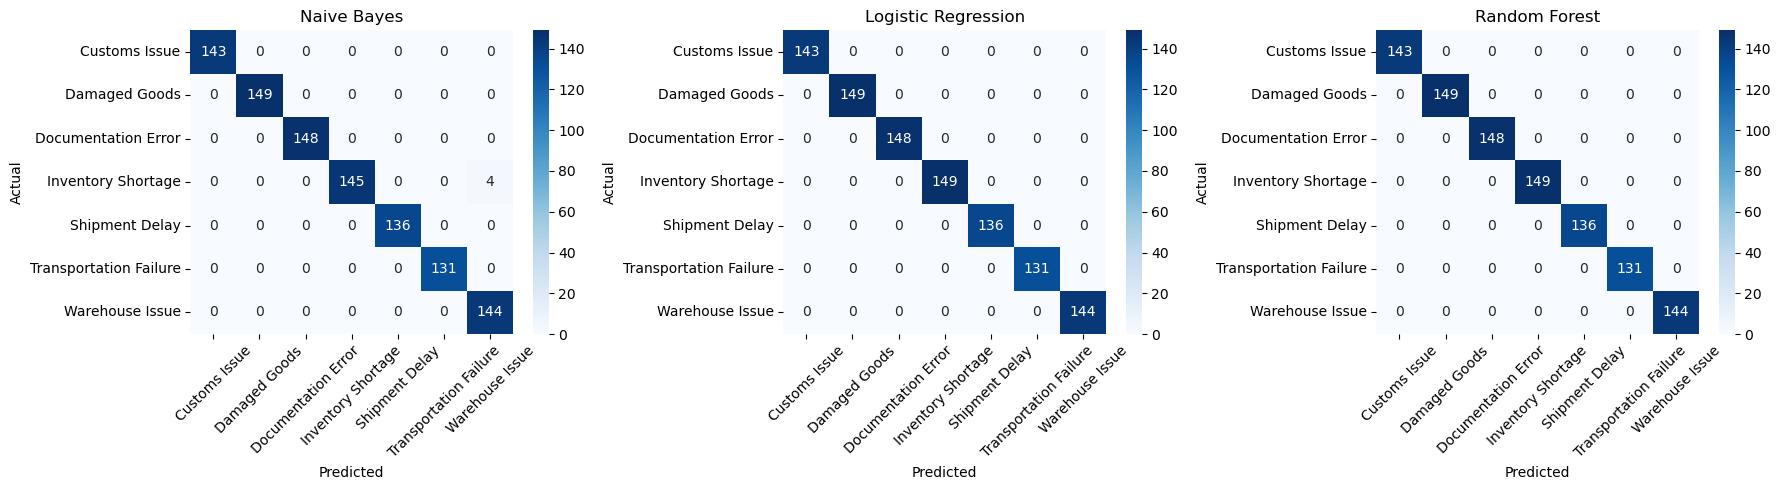

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
categories = sorted(np.unique(y_test))

for ax, y_pred, name in zip(axes, [y_pred_nb, y_pred_lr, y_pred_rf], ['Naive Bayes', 'Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred, labels=categories)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories, cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

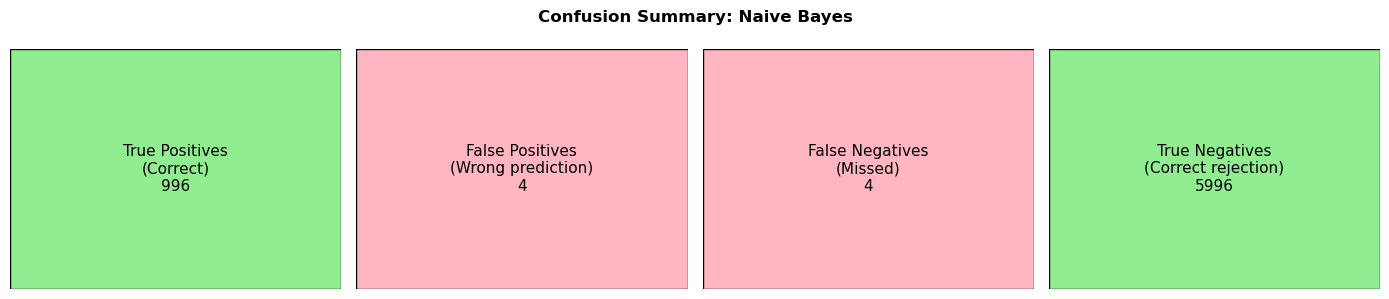

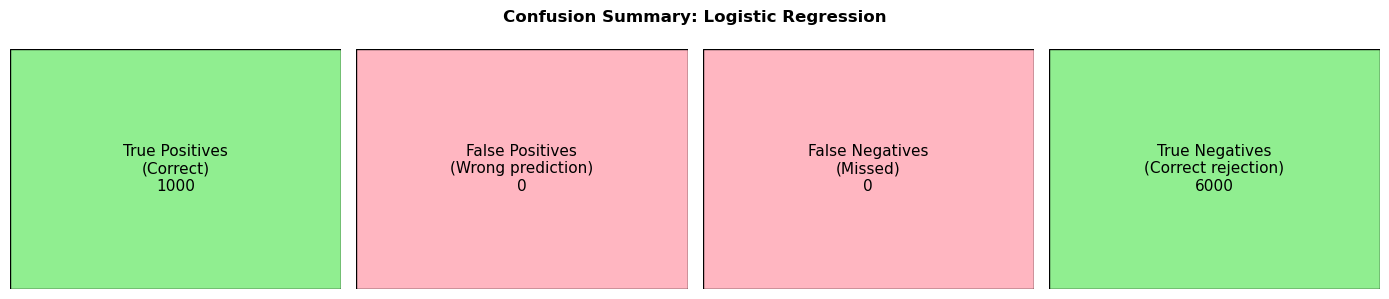

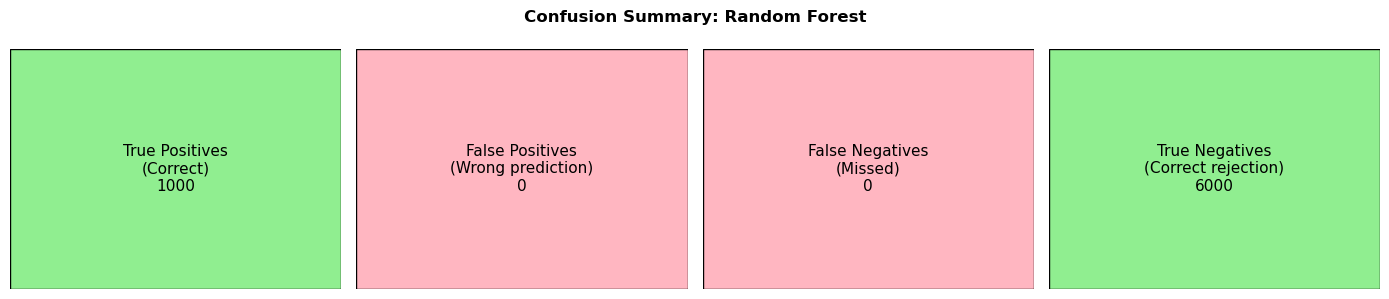

In [45]:
def plot_binary_cm(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred, labels=sorted(np.unique(y_test)))
    
    tp = np.diag(cm).sum()
    fp = (cm.sum(axis=0) - np.diag(cm)).sum()
    fn = (cm.sum(axis=1) - np.diag(cm)).sum()
    tn = sum([
        cm.sum() - cm[i,:].sum() - cm[:,i].sum() + cm[i,i]
        for i in range(len(cm))
    ])
    
    values = [tp, fp, fn, tn]
    labels = ['True Positives\n(Correct)', 'False Positives\n(Wrong prediction)', 'False Negatives\n(Missed)', 'True Negatives\n(Correct rejection)']
    colors = ['#90EE90', '#FFB6C1', '#FFB6C1', '#90EE90']
    
    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    fig.suptitle(f'Confusion Summary: {model_name}', fontweight='bold')
    
    for i, ax in enumerate(axes):
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=colors[i], ec='black'))
        ax.text(0.5, 0.5, f"{labels[i]}\n{values[i]}", ha='center', va='center', fontsize=11)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

plot_binary_cm(y_test, y_pred_nb, "Naive Bayes")
plot_binary_cm(y_test, y_pred_lr, "Logistic Regression")
plot_binary_cm(y_test, y_pred_rf, "Random Forest")

## Observations

### Accuracy
All three models performed exceptionally well on this dataset.
Logistic Regression and Random Forest both achieved 100% accuracy,
while Naive Bayes was marginally behind at 99.6%. In a real world
scenario with messier data, these numbers would be significantly lower.

### Precision
Precision measures how many of the tickets predicted as a certain
category were actually that category. Logistic Regression and Random
Forest scored 1.0, meaning every single prediction was correct.
Naive Bayes scored 0.9961, with a small number of incorrect predictions
across categories.

### Recall
Recall measures how many of the actual tickets in a category were
correctly caught by the model. Again Logistic Regression and Random
Forest scored 1.0. Naive Bayes scored 0.996, meaning it missed
a small number of tickets that belonged to certain categories.

### F1 Score
F1 is the balance between precision and recall. A score of 1.0 means
perfect balance between catching the right tickets and not
misclassifying wrong ones. Logistic Regression and Random Forest
both hit 1.0. Naive Bayes scored 0.996, reflecting its 4
misclassifications.

### Best Model
Logistic Regression and Random Forest are jointly the best models,
both achieving perfect scores across every metric. Between the two,
Logistic Regression is the more practical choice as it trains faster,
uses less memory, and achieves the same result. Random Forest builds
100 decision trees which adds computational cost with no accuracy
benefit on this dataset.

### Worst Model
Naive Bayes is the worst performing model, though only slightly.
Its 4 misclassifications are likely due to its assumption that
every word is independent of every other word. In reality, phrases
like "customs clearance" or "stock unavailable" carry meaning as a
pair that Naive Bayes fails to understand. Logistic Regression
and Random Forest both handle word relationships better.

### Note
All three models scoring at or near 100% is a direct result of the
templated structure of this dataset. Every ticket follows the same
sentence pattern and each category has a small set of highly
distinct keywords. This makes classification easy for
any model. On real unstructured incident reports with varied language,
spelling mistakes, and overlapping vocabulary, scores would drop
and the results of each model would meaningully vary.